In [28]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.utils.prune as prune
import numpy as np
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
import cv2

VGG Net

In [ ]:
class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16, self).__init__()
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # 분류기
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )
        
        # 가중치 초기화 호출
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # 평탄화
        x = self.classifier(x)
        return x

    # 중복 정의 제거된 가중치 초기화 함수
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

# VGG 모델 생성 및 파라미터 확인
vgg16_model = VGG16(num_classes=10)
print("VGG16 모델 생성 완료")

total_params = sum(p.numel() for p in vgg16_model.parameters())
trainable_params = sum(p.numel() for p in vgg16_model.parameters() if p.requires_grad)

print(f"전체 파라미터 수: {total_params:,}")
print(f"학습 가능한 파라미터 수: {trainable_params:,}")

VGG16 모델 생성 완료
전체 파라미터 수: 33,638,218
학습 가능한 파라미터 수: 33,638,218


ResNet

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(residual)
        out = self.relu(out)
        return out

# ResNet 모델
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # 4개의 레이어 그룹
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # 분류기
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

def ResNet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

def ResNet34(num_classes=10):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)

# ResNet-18 모델 생성 및 요약
resnet18_model = ResNet18()
print("Res Net-18 모델 생성 완료")

# 모델 파라미터 수 계산
resnet_params = sum(p.numel() for p in resnet18_model.parameters())
print(f"ResNet-18 파라미터 수: {resnet_params:,}")

#모델 테스트
test_input = torch.randn(1, 3, 32, 32)
resnet_output = resnet18_model(test_input)
print(f"ResNet-18 출력 크기: {resnet_output.shape}")

Res Net-18 모델 생성 완료
ResNet-18 파라미터 수: 11,173,962
ResNet-18 출력 크기: torch.Size([1, 10])


모델 경량화와 최적화

c:\Users\asus\anaconda3\envs\dmu\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\asus\anaconda3\envs\dmu\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Evaluating model before pruning...
Before pruning - Test Loss: 2.5767, Test Acc: 13.81%
Total trainable parameters before pruning: 11181642

Applying pruning...

Pruning results:
conv1: torch.Size([64, 3, 7, 7])
 Original parameters: 9408
 Remaining parameters: 6586
 Sparsity: 30.00%
layer1.0.conv1: torch.Size([64, 64, 3, 3])
 Original parameters: 36864
 Remaining parameters: 25805
 Sparsity: 30.00%
layer1.0.conv2: torch.Size([64, 64, 3, 3])
 Original parameters: 36864
 Remaining parameters: 25805
 Sparsity: 30.00%
layer1.1.conv1: torch.Size([64, 64, 3, 3])
 Original parameters: 36864
 Remaining parameters: 25805
 Sparsity: 30.00%
layer1.1.conv2: torch.Size([64, 64, 3, 3])
 Original parameters: 36864
 Remaining parameters: 25805
 Sparsity: 30.00%
layer2.0.conv1: torch.Size([128, 64, 3, 3])
 Original parameters: 73728
 Remaining parameters: 51610
 Sparsity: 30.00%
layer2.0.conv2: torch.Size([128, 128, 3, 3])
 Original parameters: 147456
 Remaining parameters: 103219
 Sparsity: 30.00%
l

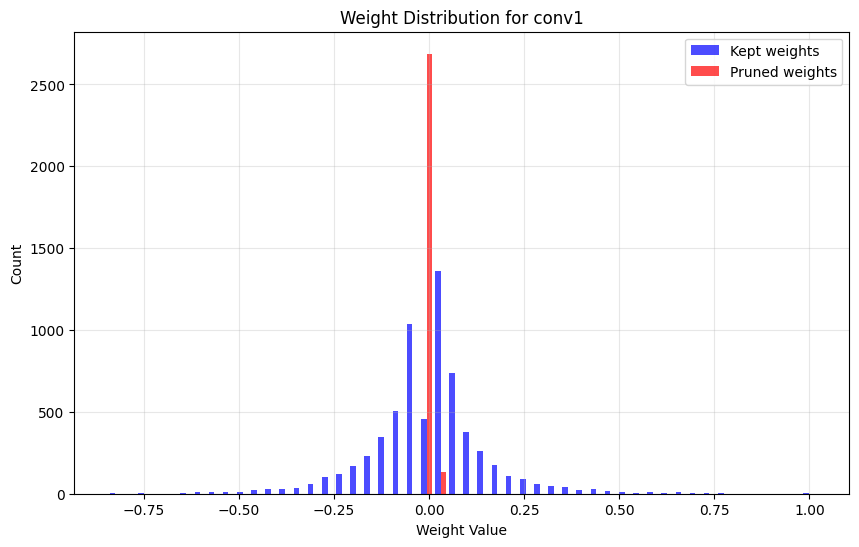


Making pruning permanent...

Evaluating model after pruning...
After pruning Test Loss: 2.5928, Test Acc: 14.76%

Accuracy change: 0.95 percentage points

Measuring inference time...
Average inference time per batch: 4824.38 ms
Pruned model saved as 'resnet18_pruned.pth'


In [31]:
# 데이터 전처리 및 모델 설정
transform_test = transforms.Compose([
    transforms.Resize(224), # ResNet18은 일반적으로 224x224 입력 크기 사용
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=160, shuffle=False, num_workers=2)

# 클래스 이름
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# 모델 평가 함수
def evaluate(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return test_loss / len(test_loader), 100. * correct / total

#모델 평가 (가지치기 전)
print("\nEvaluating model before pruning...")

#criterion 변수가 아직 정의되지 않았으므로 CrossEntropy Loss를 사용
criterion = nn.CrossEntropyLoss()
test_loss_before, test_acc_before = evaluate(model, test_loader, criterion, device)
print(f'Before pruning - Test Loss: {test_loss_before:.4f}, Test Acc: {test_acc_before:.2f}%')

total_params_before = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters before pruning: {total_params_before}')

# 가지치기(Pruning) 적용
print("\nApplying pruning...")

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.l1_unstructured(module, name='weight', amount=0.3) # 가중치의 30% 제거
print("\nPruning results:")

pruned_layers = 0
total_params_pruned = 0
total_params = 0

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        pruned_layers += 1
        orig_params = module.weight.numel()
        remaining_params = torch.sum(module.weight != 0).item()
        pruned_params = orig_params - remaining_params
        sparsity = 100 * (1 - remaining_params / orig_params)
        
        total_params += orig_params
        total_params_pruned += pruned_params
        
        print(f'{name}: {module.weight.shape}')
        print(f' Original parameters: {orig_params}')
        print(f' Remaining parameters: {remaining_params}')
        print(f' Sparsity: {sparsity:.2f}%')

overall_sparsity = 100 * (total_params_pruned / total_params) if total_params > 0 else 0
print(f'Overall Conv2d layer sparsity: {overall_sparsity:.2f}%')
print(f'Total pruned layers: {pruned_layers}')

# 가지치기 결과 가중치 시각화 함수
def plot_weight_distribution(model, layer_name):
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, nn.Conv2d):
            orig_weight = module.weight_orig.detach().cpu().numpy().flatten()
            mask = module.weight_mask.detach().cpu().numpy().flatten()
            
            pruned_indices = np.where(mask == 0)[0]
            pruned_weights = orig_weight[pruned_indices]
            
            kept_indices = np.where(mask != 0)[0]
            kept_weights = orig_weight[kept_indices]
            
            plt.figure(figsize=(10,6))
            plt.hist([kept_weights, pruned_weights], bins=50, label=['Kept weights', 'Pruned weights'], alpha=0.7, color=['blue', 'red'])
            plt.xlabel('Weight Value')
            plt.ylabel('Count')
            plt.title(f'Weight Distribution for {layer_name}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
            break

# 첫 번째 합성곱 레이어의 가중치 분포 시각화
plot_weight_distribution(model, 'conv1')

# 영구적으로 가지치기 적용
print("\nMaking pruning permanent...")
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.remove(module, 'weight')

# 가지치기 적용 후 모델 평가
print("\nEvaluating model after pruning...")
test_loss_after, test_acc_after = evaluate(model, test_loader, criterion, device)
print(f'After pruning Test Loss: {test_loss_after:.4f}, Test Acc: {test_acc_after:.2f}%')

# 성능 변화 보고
acc_change = test_acc_after - test_acc_before
print(f'\nAccuracy change: {acc_change:.2f} percentage points')

# 추론 시간 측정 함수
def measure_inference_time(model, test_loader, device, num_batches=100):
    model.eval()
    total_time = 0
    batch_count = 0
    with torch.no_grad():
        for inputs, _ in test_loader:
            if batch_count >= num_batches:
                break
            inputs = inputs.to(device)
            start_time = time.time()
            _ = model(inputs)
            end_time = time.time()
            total_time += (end_time - start_time)
            batch_count += 1
        avg_time = total_time / batch_count
        return avg_time

print("\nMeasuring inference time...")

inference_time = measure_inference_time(model, test_loader, device)
print(f'Average inference time per batch: {inference_time*1000:.2f} ms')

# 모델 저장(선택 사항)
torch.save(model.state_dict(), 'resnet18_pruned.pth')
print("Pruned model saved as 'resnet18_pruned.pth'")

In [32]:
# 모델 파라미터 수 및 크기 추정 함수
def count_parameters(model):
    #모델의 파라미터 수 계산
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params

def estimate_model_size(model):
    #모델 크기 추정(MB)
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    size_mb = (param_size + buffer_size) / 1024 /1024

    return size_mb


# 양자화용 모델(더 간단한 버전)
class SimpleQuantModel(nn.Module):
    def __init__(self):
        super(SimpleQuantModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc = nn.Linear(32 * 8 * 8, 10)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        
        return x

In [33]:
# 원본 모델 생성
original_model = SimpleQuantModel()
print("양자화 전 모델 정보:")
print(f"모델 파라미터 수: {count_parameters(original_model):.2f}")

#더미 데이터로 모델 크기 추정
original_size = estimate_model_size(original_model)
print(f"모델 크기: {original_size:.2f} MB")

#양자화를 위한 더미 데이터
dummy_data = torch.randn(10, 3, 32, 32)

# Post-training quantization(동적 양자화)
print("\n동적 양자화 적용 중...")
quantized_model = torch.quantization.quantize_dynamic(original_model, {nn.Linear, nn.Conv2d}, dtype=torch.qint8)
quantized_size = estimate_model_size(quantized_model)

print(f"양자화된 모델 크기: {quantized_size:.2f} MB")
print(f"크기 감소율: {(original_size - quantized_size) / original_size * 100:1f}%")

#성능 비교(더미 데이터)
print("\n성능 비교:")
original_model.eval()
quantized_model.eval()

with torch.no_grad():
    original_output = original_model(dummy_data)
    quantized_output = quantized_model(dummy_data)

#MSE 계산
mse = torch.mean((original_output - quantized_output) ** 2).item()
print(f"원본과 양자화 모델 간 MSE: {mse:.6f}")
      
#양자화 세부 정보 출력
print("\n양자화 세부 정보:")
print("양자화된 레이어:")

for name, module in quantized_model.named_modules():
    if hasattr(module, 'weight') and hasattr(module.weight, 'dtype'):
        print(f" {name}: {module.weight.dtype}")
        
print("\n양자화 완료!")

양자화 전 모델 정보:
모델 파라미터 수: 25578.00
모델 크기: 0.10 MB

동적 양자화 적용 중...
양자화된 모델 크기: 0.02 MB
크기 감소율: 80.107905%

성능 비교:
원본과 양자화 모델 간 MSE: 0.000003

양자화 세부 정보:
양자화된 레이어:
 conv1: torch.float32
 conv2: torch.float32

양자화 완료!


C:\Users\asus\AppData\Local\Temp\ipykernel_9508\838342621.py:15: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(original_model, {nn.Linear, nn.Conv2d}, dtype=torch.qint8)


지식 증류

In [34]:
# Teacher 모델 구현 (큰 모델)
class TeacherModel(nn.Module):
    def __init__(self):
        super(TeacherModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Student 모델 구현 (작은 모델)
class StudentModel(nn.Module):
    def __init__(self):
        super(StudentModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        # CIFAR-10(32x32) 입력 기준, Pool 2번 거치면 8x8이 됨
        self.fc = nn.Linear(32 * 8 * 8, 10)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# 지식 증류 손실 함수 구현
class DistillationLoss(nn.Module):
    def __init__(self, temperature=3.0, alpha=0.7):
        super(DistillationLoss, self).__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.kl_div = nn.KLDivLoss(reduction='batchmean')
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_outputs, teacher_outputs, labels):
        # 지식 증류 손실 (Soft Target 학습)
        teacher_probs = F.softmax(teacher_outputs / self.temperature, dim=1)
        student_log_probs = F.log_softmax(student_outputs / self.temperature, dim=1)
        
        distillation_loss = self.kl_div(student_log_probs, teacher_probs) * (self.temperature ** 2)
        
        # 일반 분류 손실 (Hard Target 학습)
        classification_loss = self.ce_loss(student_outputs, labels)
        
        # 총 손실 계산
        total_loss = (self.alpha * distillation_loss) + ((1 - self.alpha) * classification_loss)

        return total_loss, distillation_loss, classification_loss

# 실행 및 결과 확인
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

teacher_model = TeacherModel()
student_model = StudentModel()

print("모델 비교:")
print(f"Teacher 모델 파라미터 수: {count_parameters(teacher_model):,}")
print(f"Student 모델 파라미터 수: {count_parameters(student_model):,}")

reduction = (1 - count_parameters(student_model) / count_parameters(teacher_model)) * 100
print(f"파라미터 감소율: {reduction:.1f}%")

# 지식 증류 데모 (더미 데이터)
print("\n지식 증류 데모:")
dummy_input = torch.randn(4, 3, 32, 32)
dummy_labels = torch.randint(0, 10, (4,))

teacher_model.eval()
student_model.train()

with torch.no_grad():
    t_outputs = teacher_model(dummy_input)

s_outputs = student_model(dummy_input)
loss_fn = DistillationLoss()
total_loss, d_loss, c_loss = loss_fn(s_outputs, t_outputs, dummy_labels)

print(f"총 손실: {total_loss.item():.4f}")
print(f"증류 손실: {d_loss.item():.4f}")
print(f"분류 손실: {c_loss.item():.4f}")

모델 비교:
Teacher 모델 파라미터 수: 2,473,610
Student 모델 파라미터 수: 25,578
파라미터 감소율: 99.0%

지식 증류 데모:
총 손실: 0.6774
증류 손실: 0.0178
분류 손실: 2.2162


CAM

CAM 테스트 시작
예측된 클래스 : 3


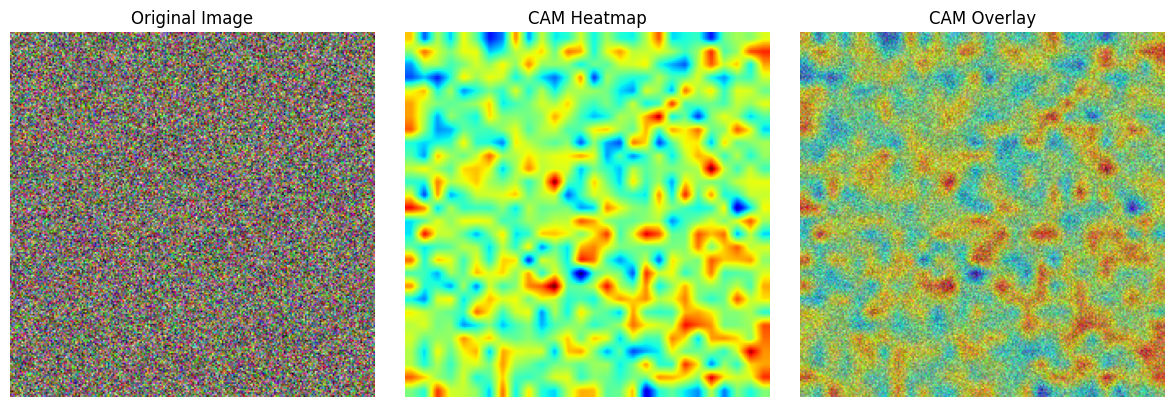

In [35]:
# CAM 구현을 위한 수정된 ResNet 구조
class CAMResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(CAMResNet, self).__init__()
        # 기본 특성 추출 레이어들 (Sequential 내부에 포함)
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Global Average Pooling (GAP)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
        
        # CAM 생성을 위한 특성 맵 저장 변수
        self.feature_maps = None

    def forward(self, x):
        x = self.features(x)
        self.feature_maps = x  # 마지막 컨볼루션 층의 특성 맵 저장
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def get_cam(self, class_idx):
        # FC 레이어의 가중치 중 해당 클래스에 해당하는 것만 추출
        fc_weights = self.fc.weight.data[class_idx].cpu().numpy()
        # 저장된 특성 맵 추출 (배치 첫 번째 이미지 기준)
        fmaps = self.feature_maps.detach().cpu().numpy()[0]
        
        # 가중치와 특성 맵의 선형 결합 (Weighted Sum)
        cam = np.zeros(fmaps.shape[1:], dtype=np.float32)
        for i, w in enumerate(fc_weights):
            cam += w * fmaps[i]
            
        # ReLU 적용 및 정규화
        cam = np.maximum(cam, 0)
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)

        return cam

# CAM 시각화 함수
def visualize_cam(image, cam):
    # 이미지 역정규화 및 변환 (H, W, C)
    img_np = image[0].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # CAM을 원본 이미지 크기로 확장
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    
    # 히트맵 생성
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) # OpenCV BGR -> RGB 변환
    heatmap = np.float32(heatmap) / 255

    # 원본 이미지와 히트맵 합성
    superimposed_img = heatmap + img_np
    superimposed_img = superimposed_img / np.max(superimposed_img)

    # 결과 출력
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np); plt.title("Original Image"); plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap='jet'); plt.title("CAM Heatmap"); plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img); plt.title("CAM Overlay"); plt.axis('off')
    plt.tight_layout()
    plt.show()

# 실행 및 테스트
cam_model = CAMResNet(num_classes=10)
cam_model.eval()

print("CAM 테스트 시작")
dummy_input = torch.randn(1, 3, 224, 224)
output = cam_model(dummy_input)
_, predicted_class = torch.max(output, 1)

print(f"예측된 클래스 : {predicted_class.item()}")

# CAM 계산 및 시각화 실행
cam_result = cam_model.get_cam(predicted_class.item())
visualize_cam(dummy_input, cam_result)

Grad-CAM

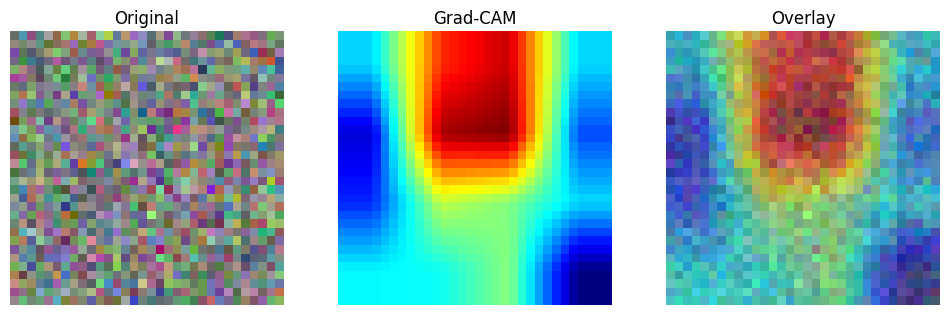


실행 완료 : Grad-CAM 생성 및 시각화


In [36]:
# Grad-CAM 클래스 구현
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # 훅(Hook) 등록 : 특성 맵과 기울기를 가로챔
        def forward_hook(module, input, output):
            self.activations = output.detach()
            
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
            
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, x, class_idx=None):
        output = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
            
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        # 가중치 계산 (GAP)
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        # Grad-CAM 생성
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam) # ReLU 적용
        
        # 입력 이미지 크기로 리사이즈 및 정규화
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy()

# 모델 정의 (ResNet18)
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [BasicBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = self.avgpool(x)
        return self.fc(x.view(x.size(0), -1))

# 시각화 함수
def visualize_grad_cam(original_img, cam):
    if isinstance(original_img, torch.Tensor):
        img_np = original_img[0].permute(1, 2, 0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    
    h, w = img_np.shape[:2]
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    
    alpha = 0.5
    superimposed_img = heatmap * alpha + img_np * (1 - alpha)
    
    plt.figure(figsize=(12, 4))

    titles = ['Original', 'Grad-CAM', 'Overlay']
    imgs = [img_np, heatmap, superimposed_img]

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(imgs[i]); plt.title(titles[i]); plt.axis('off')
    plt.show()

# 실행
model = ResNet18().eval()
target_layer = model.layer4[-1].conv2 # 마지막 conv 레이어 설정
grad_cam = GradCAM(model, target_layer)

dummy_input = torch.randn(1, 3, 32, 32)
output = model(dummy_input)
_, pred = torch.max(output, 1)

cam_result = grad_cam(dummy_input, pred.item())
visualize_grad_cam(dummy_input, cam_result)

print("\n실행 완료 : Grad-CAM 생성 및 시각화")